In [1]:
import pandas as pd
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('PhuLien_bochoi.csv')

In [3]:
data_melted = data.melt(id_vars=["Year"], var_name="Month", value_name="Value")

# Converting Year and Month to a datetime object
data_melted["Date"] = pd.to_datetime(data_melted["Year"].astype(str) + data_melted["Month"], format="%Y%m")

# Dropping the old Year and Month columns
data_melted.drop(["Year", "Month"], axis=1, inplace=True)

# Setting the Date as index
data_melted.set_index("Date", inplace=True)

# Sorting the dataframe by date
data_melted.sort_index(inplace=True)

# Display the transfo
train_end = pd.to_datetime("1995")
train_data = data_melted[:train_end]
test_data = data_melted[train_end + pd.Timedelta(days=1):]

# Displaying the last few rows of the training data and the first few rows of the test data
train_data.tail(), test_data.tail()

(            Value
 Date             
 1994-09-01   47.6
 1994-10-01   79.1
 1994-11-01   74.6
 1994-12-01   39.0
 1995-01-01   34.5,
             Value
 Date             
 2015-08-01   79.5
 2015-09-01   49.8
 2015-10-01   63.5
 2015-11-01   66.6
 2015-12-01   66.4)

In [4]:
auto_model = auto_arima(train_data, start_p=0, start_q=0,
                        test='adf',  # Use adf test to find optimal 'd'
                        max_p=5, max_q=5,  # Maximum p and q
                        m=12,  # Frequency of the series
                        d=None,  # Let model determine 'd'
                        seasonal=True,  # Modeling seasonal component
                        start_P=0, D=0, trace=True,
                        error_action='ignore',  
                        suppress_warnings=True, 
                        stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=3939.760, Time=0.68 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=3985.470, Time=0.06 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=3882.356, Time=0.98 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=3911.809, Time=0.48 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=4838.706, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=3925.759, Time=0.12 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=3821.117, Time=2.45 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=3817.827, Time=4.65 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=3823.082, Time=1.10 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=3841.752, Time=3.05 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=3811.678, Time=2.21 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=3858.733, Time=1.08 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=3903.366, Time=0.47 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=3812.774, Time=3.27 sec
 ARIMA(2,0,0)(1,0,2

In [5]:
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                       y   No. Observations:                  433
Model:             SARIMAX(0, 0, 1)x(1, 0, [1, 2], 12)   Log Likelihood               -1899.032
Date:                                 Fri, 23 Feb 2024   AIC                           3810.064
Time:                                         08:20:59   BIC                           3834.488
Sample:                                     01-01-1959   HQIC                          3819.706
                                          - 01-01-1995                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      6.3652      2.890      2.203      0.028       0.701      12.029
ma.L1          0.0931      0.034      2.721      0.007       0.026       0.160
ar.S.L12       0.8922      0.046     19.365      0.000       0.802       0.982
ma.S.L12      -0.7304      0.064    -11.352      0.000      -0.857      -0.604
ma.S.L24       0.1123      0.051      2.209      0.027       0.013       0.212
sigma2       377.4244      7.214     52.316      0.000     363.285     391.564
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):             28924.02
Prob(Q):                              0.77   Prob(JB):                         0.00
Heteroskedasticity (H):               0.43   Skew:                             3.85
Prob(H) (two-sided):                  0.00   Kurtosis:                        42.29
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [6]:
model = SARIMAX(train_data, order=auto_model.order, seasonal_order=auto_model.seasonal_order)
model_fit = model.fit(disp=False)

C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\HON\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [7]:
predictions = model_fit.predict(start=test_data.index[0], end=test_data.index[-1])
predictions.head()

1995-02-01    31.388892
1995-03-01    31.388120
1995-04-01    37.314231
1995-05-01    60.605155
1995-06-01    71.231325
Freq: MS, Name: predicted_mean, dtype: float64

In [8]:
comparison = pd.DataFrame({'Actual': test_data["Value"], 'Predicted': predictions})

comparison

,Actual,Predicted
1995-02-01,25.8,31.388892
1995-03-01,24.9,31.388120
1995-04-01,25.2,37.314231
1995-05-01,58.1,60.605155
1995-06-01,55.8,71.231325
...,...,...
2015-08-01,79.5,59.911131
2015-09-01,49.8,60.877712
2015-10-01,63.5,80.827993
2015-11-01,66.6,78.805677


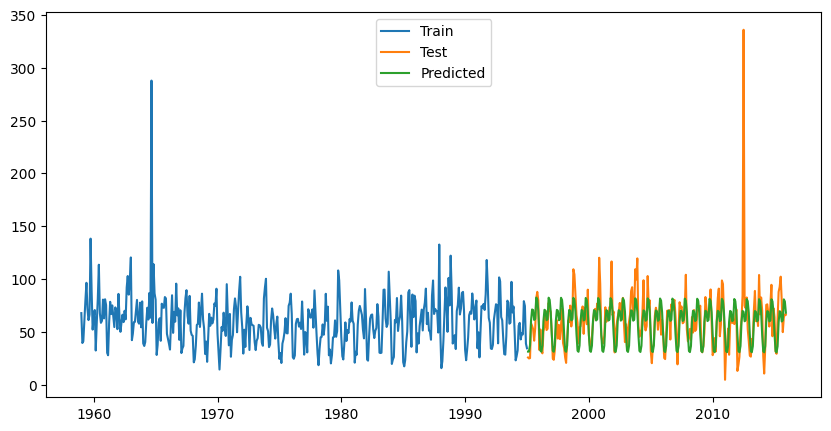

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(train_data.index, train_data, label='Train')
plt.plot(test_data.index, test_data, label='Test')
plt.plot(predictions.index, predictions, label='Predicted')
plt.legend()
plt.show()

In [10]:
rmse = sqrt(mean_squared_error(test_data, predictions))
print(f"RMSE: {rmse}")

RMSE: 22.333433718610994
